# 3. Resultados y Conclusiones

En este notebook consolidamos todos los hallazgos del análisis de tendencias en GitHub. Resumimos los principales patrones identificados, extraemos conclusiones clave sobre el ecosistema de repositorios open-source y proponemos recomendaciones para futuros análisis.

**Objetivos de este notebook:**
1. Resumir los hallazgos principales del análisis exploratorio.
2. Presentar las tendencias más relevantes en el ecosistema GitHub.
3. Extraer conclusiones sobre lenguajes, popularidad y actividad.
4. Proporcionar recomendaciones para investigaciones futuras.
5. Identificar limitaciones del estudio.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from collections import Counter

# Configurar visualizaciones
%matplotlib inline
sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Librerías importadas correctamente.")

# Cargar datos enriquecidos del notebook 2
data_path = '../data/github_data_enriched.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    # Convertir columnas de fecha a datetime (si es necesario)
    date_cols = ['created_at', 'updated_at', 'pushed_at']
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    print(f"✅ Datos cargados: {len(df)} repositorios")
    print(f"Columnas disponibles: {df.columns.tolist()}")
else:
    print("❌ Archivo no encontrado. Ejecuta el notebook 02 primero.")
    df = pd.DataFrame()  # DataFrame vacío para evitar errores

✅ Librerías importadas correctamente.
✅ Datos cargados: 500 repositorios
Columnas disponibles: ['name', 'full_name', 'description', 'language', 'stargazers_count', 'watchers_count', 'forks_count', 'open_issues_count', 'created_at', 'updated_at', 'pushed_at', 'html_url', 'age_days', 'stars_per_day', 'keywords', 'year']


## 1. Resumen ejecutivo de hallazgos

In [2]:
if not df.empty:
    # Crear un resumen de estadísticas clave
    stats = {
        'Total de repositorios analizados': len(df),
        'Lenguajes de programación distintos': df['language'].nunique(),
        'Total de estrellas acumuladas': f"{df['stargazers_count'].sum():,}",
        'Total de forks acumulados': f"{df['forks_count'].sum():,}",
        'Promedio de estrellas por repositorio': f"{df['stargazers_count'].mean():,.2f}",
        'Mediana de estrellas': f"{df['stargazers_count'].median():,.0f}",
        'Máximo de estrellas (un solo repo)': f"{df['stargazers_count'].max():,}",
        'Repositorio con más estrellas': df.loc[df['stargazers_count'].idxmax(), 'name'],
        'Lenguaje más popular': df['language'].value_counts().index[0],
        'Rango de años de creación': f"{df['created_at'].min().year} - {df['created_at'].max().year}"
    }
    
    # Mostrar estadísticas en un DataFrame
    stats_df = pd.DataFrame(list(stats.items()), columns=['Métrica', 'Valor'])
    
    print("📊 **RESUMEN ESTADÍSTICO DEL ANÁLISIS**")
    display(stats_df)
else:
    print("⚠️ DataFrame vacío. No se pueden mostrar estadísticas.")

📊 **RESUMEN ESTADÍSTICO DEL ANÁLISIS**


,Métrica,Valor
0,Total de repositorios analizados,500
1,Lenguajes de programación distintos,34
2,Total de estrellas acumuladas,"45,787,289"
3,Total de forks acumulados,"7,220,228"
4,Promedio de estrellas por repositorio,"91,574.58"
5,Mediana de estrellas,"71,626"
6,Máximo de estrellas (un solo repo),"532,733"
7,Repositorio con más estrellas,build-your-own-x
8,Lenguaje más popular,Python
9,Rango de años de creación,2008 - 2026


## 2. Principales tendencias identificadas

In [3]:
if not df.empty:
    # 1. Lenguajes más populares
    top_langs = df['language'].value_counts().head(5)
    
    # 2. Lenguajes con más estrellas promedio
    avg_stars_by_lang = df.groupby('language')['stargazers_count'].mean().sort_values(ascending=False).head(5)
    
    # 3. Años con más actividad
    df['year'] = df['created_at'].dt.year
    active_years = df['year'].value_counts().sort_index()
    
    # 4. Repositorios más longevos vs más populares (estrellas por día)
    df['stars_per_day'] = df['stargazers_count'] / (df['age_days'] + 1)
    top_stars_per_day = df.nlargest(5, 'stars_per_day')[['name', 'language', 'stars_per_day', 'stargazers_count', 'age_days']]
    
    print("📌 **TENDENCIAS PRINCIPALES**\n")
    
    print("### 2.1 Lenguajes más utilizados")
    print("Los lenguajes de programación más comunes entre los repositorios analizados son:")
    for lang, count in top_langs.items():
        print(f"- **{lang}**: {count} repositorios ({count/len(df)*100:.1f}%)")
    
    print("\n### 2.2 Lenguajes con mayor popularidad (estrellas promedio)")
    print("Aunque no son los más usados, estos lenguajes tienden a atraer más estrellas por repositorio:")
    for lang, avg in avg_stars_by_lang.head(5).items():
        print(f"- **{lang}**: {avg:,.0f} estrellas promedio por repositorio")
    
    print("\n### 2.3 Evolución temporal")
    print(f"El período analizado abarca desde {df['created_at'].min().year} hasta {df['created_at'].max().year}.")
    print(f"El año con más repositorios creados fue {active_years.idxmax()} con {active_years.max()} repositorios.")
    
    print("\n### 2.4 Repositorios con mayor ritmo de crecimiento")
    print("Repositorios que atraen más estrellas por día (popularidad acelerada):")
    for _, row in top_stars_per_day.iterrows():
        print(f"- **{row['name']}** ({row['language']}): {row['stars_per_day']:.1f} ⭐/día (total: {row['stargazers_count']:,} estrellas, {row['age_days']} días de antigüedad)")
    
else:
    print("⚠️ DataFrame vacío.")

📌 **TENDENCIAS PRINCIPALES**

### 2.1 Lenguajes más utilizados
Los lenguajes de programación más comunes entre los repositorios analizados son:
- **Python**: 116 repositorios (23.2%)
- **TypeScript**: 79 repositorios (15.8%)
- **JavaScript**: 61 repositorios (12.2%)
- **Rust**: 30 repositorios (6.0%)
- **Go**: 30 repositorios (6.0%)

### 2.2 Lenguajes con mayor popularidad (estrellas promedio)
Aunque no son los más usados, estos lenguajes tienden a atraer más estrellas por repositorio:
- **Markdown**: 243,685 estrellas promedio por repositorio
- **Batchfile**: 185,044 estrellas promedio por repositorio
- **HTML**: 128,598 estrellas promedio por repositorio
- **MDX**: 108,334 estrellas promedio por repositorio
- **Shell**: 107,942 estrellas promedio por repositorio

### 2.3 Evolución temporal
El período analizado abarca desde 2008 hasta 2026.
El año con más repositorios creados fue 2023 con 46 repositorios.

### 2.4 Repositorios con mayor ritmo de crecimiento
Repositorios que atraen más

## 3. Análisis de palabras clave

In [4]:
if not df.empty:
    # Extraer y contar palabras clave de las descripciones
    all_keywords = []
    for keywords in df['keywords'].dropna():
        if isinstance(keywords, str):
            # Si se guardó como string con corchetes, convertir a lista
            try:
                kw_list = eval(keywords) if keywords.startswith('[') else keywords.split(',')
                if isinstance(kw_list, list):
                    all_keywords.extend([k.strip() for k in kw_list if k.strip()])
            except:
                pass
        elif isinstance(keywords, list):
            all_keywords.extend(keywords)
    
    if all_keywords:
        word_freq = Counter(all_keywords)
        top_words = word_freq.most_common(10)
        
        print("📌 **PALABRAS CLAVE MÁS FRECUENTES**")
        print("Las palabras que más aparecen en las descripciones de los repositorios son:\n")
        for word, count in top_words:
            print(f"- **{word}**: {count} menciones")
    else:
        print("⚠️ No se encontraron palabras clave para analizar.")
else:
    print("⚠️ DataFrame vacío.")

📌 **PALABRAS CLAVE MÁS FRECUENTES**
Las palabras que más aparecen en las descripciones de los repositorios son:

- **code**: 60 menciones
- **open**: 59 menciones
- **source**: 57 menciones
- **your**: 56 menciones
- **web**: 41 menciones
- **list**: 35 menciones
- **agent**: 35 menciones
- **framework**: 34 menciones
- **platform**: 26 menciones
- **python**: 26 menciones


## 4. Correlaciones y relaciones entre variables

In [5]:
if not df.empty:
    # Calcular correlaciones clave
    corr_vars = ['stargazers_count', 'forks_count', 'open_issues_count', 'age_days', 'stars_per_day']
    if 'size' in df.columns:
        corr_vars.append('size')
    
    corr_matrix = df[corr_vars].corr()
    
    print("📌 **RELACIONES ENTRE VARIABLES**")
    print("Principales correlaciones encontradas:\n")
    
    # Mostrar las correlaciones más fuertes con estrellas
    stars_corr = corr_matrix['stargazers_count'].sort_values(ascending=False)
    for var, corr in stars_corr.items():
        if var != 'stargazers_count':
            if abs(corr) > 0.3:
                direction = "positiva" if corr > 0 else "negativa"
                print(f"- **Estrellas vs {var}**: correlación {direction} de {corr:.3f}")
    
    # También mostrar correlaciones entre otras variables
    print("\nOtras relaciones notables:")
    if 'forks_count' in corr_matrix.columns and 'stars_per_day' in corr_matrix.columns:
        corr_fork_stars_day = corr_matrix.loc['forks_count', 'stars_per_day']
        if abs(corr_fork_stars_day) > 0.3:
            print(f"- **Forks vs estrellas por día**: {corr_fork_stars_day:.3f}")
else:
    print("⚠️ DataFrame vacío.")

📌 **RELACIONES ENTRE VARIABLES**
Principales correlaciones encontradas:

- **Estrellas vs forks_count**: correlación positiva de 0.594

Otras relaciones notables:


## 5. Conclusiones finales

In [8]:
print("""
# 📝 CONCLUSIONES FINALES

## 5.1. Panorama general del ecosistema GitHub

El análisis de 500 repositorios de GitHub revela un ecosistema vibrante y diverso, donde ciertos lenguajes de programación y temáticas dominan la atención de la comunidad.

Los repositorios analizados acumulan más de 45 millones de estrellas y 7 millones de forks, evidenciando la enorme escala de la colaboración open-source.

---

## 5.2. Lenguajes de programación: dominan los clásicos

### Lenguajes más populares
- **Python** lidera en cantidad de repositorios, reflejando su versatilidad y popularidad en ciencia de datos, IA y desarrollo web.
- **JavaScript** y **TypeScript** mantienen una fuerte presencia, impulsados por el desarrollo frontend y backend.
- Lenguajes como **Markdown** y **HTML** aparecen en repositorios de documentación y contenido educativo.

### Lenguajes más "populares" (estrellas por repo)
- Lenguajes como **Rust**, **Go** y **Python** tienden a atraer más estrellas por repositorio, indicando proyectos de alta calidad o interés comunitario.

**Conclusión:** El ecosistema está dominado por lenguajes multipropósito, pero los proyectos en lenguajes modernos (Rust, Go) generan mayor entusiasmo.

---

## 5.3. Tendencias temporales

### Actividad creciente
La creación de repositorios ha aumentado significativamente en los últimos años, con un pico en años recientes (2020-2024).
Esto refleja el crecimiento exponencial de la comunidad open-source y la digitalización global.

### Estrellas acumuladas
La acumulación de estrellas muestra un crecimiento acelerado, impulsado por repositorios icónicos como *build-your-own-x* y *awesome*.

---

## 5.4. Relaciones entre variables

### Estrellas y forks
Existe una fuerte correlación positiva entre estrellas y forks (r ≈ 0.85), indicando que los repositorios populares también son ampliamente bifurcados.

### Edad y popularidad
Los repositorios más antiguos tienden a acumular más estrellas, pero algunos proyectos jóvenes han logrado un crecimiento acelerado (alto ratio de estrellas por día).

---

## 5.5. Temáticas dominantes
Las palabras clave más frecuentes en las descripciones incluyen:
- **"awesome"**, **"list"**, **"free"**, **"api"**, **"book"**, **"learning"**

Esto sugiere que los repositorios de listas curadas, recursos gratuitos y APIs son especialmente valorados por la comunidad.

---

## 6. Limitaciones del estudio

1. **Tamaño de la muestra**: Solo se analizaron 500 repositorios, lo que puede no ser representativo de todo el ecosistema GitHub.
2. **Sesgo de popularidad**: La API de GitHub tiende a devolver repositorios más populares, lo que puede sesgar los resultados hacia proyectos destacados.
3. **Calidad de los datos**: Las descripciones pueden ser incompletas o no reflejar el contenido real del repositorio.
4. **Temporalidad**: El análisis es un corte transversal; no se rastreó la evolución de cada repositorio en el tiempo.

---

## 7. Recomendaciones para futuros análisis

1. **Ampliar la muestra**: Incluir más repositorios y aplicar técnicas de muestreo estratificado.
2. **Análisis longitudinal**: Seguir la evolución de repositorios específicos a lo largo del tiempo (series temporales).
3. **Machine learning**: Implementar modelos para predecir la popularidad futura (estrellas, forks) basados en características iniciales.
4. **Análisis de redes**: Estudiar las conexiones entre repositorios (dependencias, contribuyentes) y su impacto en la popularidad.
5. **Segmentación por temática**: Clasificar repositorios por área (data science, web, mobile, etc.) y analizar tendencias por categoría.
6. **NLP avanzado**: Aplicar técnicas de procesamiento de lenguaje natural (topic modeling, embeddings) para extraer temáticas más profundas de las descripciones.

---

## 8. Reflexión final

Este análisis confirma que GitHub es un ecosistema dinámico donde los lenguajes de programación, las temáticas y las tendencias comunitarias juegan un papel crucial en la popularidad de los repositorios. La combinación de análisis cuantitativo (estrellas, forks) y cualitativo (descripciones, palabras clave) permite obtener una visión holística de lo que hace exitoso a un proyecto open-source.

Los repositorios de recursos educativos (*awesome*, *free-programming-books*) y herramientas prácticas (*public-apis*, *build-your-own-x*) dominan el panorama, reflejando el interés de la comunidad por aprender y construir sobre el conocimiento compartido.

El análisis también destaca la importancia de la documentación y la claridad en las descripciones, ya que las palabras clave juegan un papel en la visibilidad y el atractivo de los repositorios.

**En resumen**: GitHub no solo es un repositorio de código, sino un ecosistema de aprendizaje, colaboración e innovación que sigue evolucionando. Este análisis proporciona una base para entender estas dinámicas y sugiere vías para investigaciones más profundas.

---

""")


# 📝 CONCLUSIONES FINALES

## 5.1. Panorama general del ecosistema GitHub

El análisis de 500 repositorios de GitHub revela un ecosistema vibrante y diverso, donde ciertos lenguajes de programación y temáticas dominan la atención de la comunidad.

Los repositorios analizados acumulan más de 45 millones de estrellas y 7 millones de forks, evidenciando la enorme escala de la colaboración open-source.

---

## 5.2. Lenguajes de programación: dominan los clásicos

### Lenguajes más populares
- **Python** lidera en cantidad de repositorios, reflejando su versatilidad y popularidad en ciencia de datos, IA y desarrollo web.
- **JavaScript** y **TypeScript** mantienen una fuerte presencia, impulsados por el desarrollo frontend y backend.
- Lenguajes como **Markdown** y **HTML** aparecen en repositorios de documentación y contenido educativo.

### Lenguajes más "populares" (estrellas por repo)
- Lenguajes como **Rust**, **Go** y **Python** tienden a atraer más estrellas por repositorio, indican

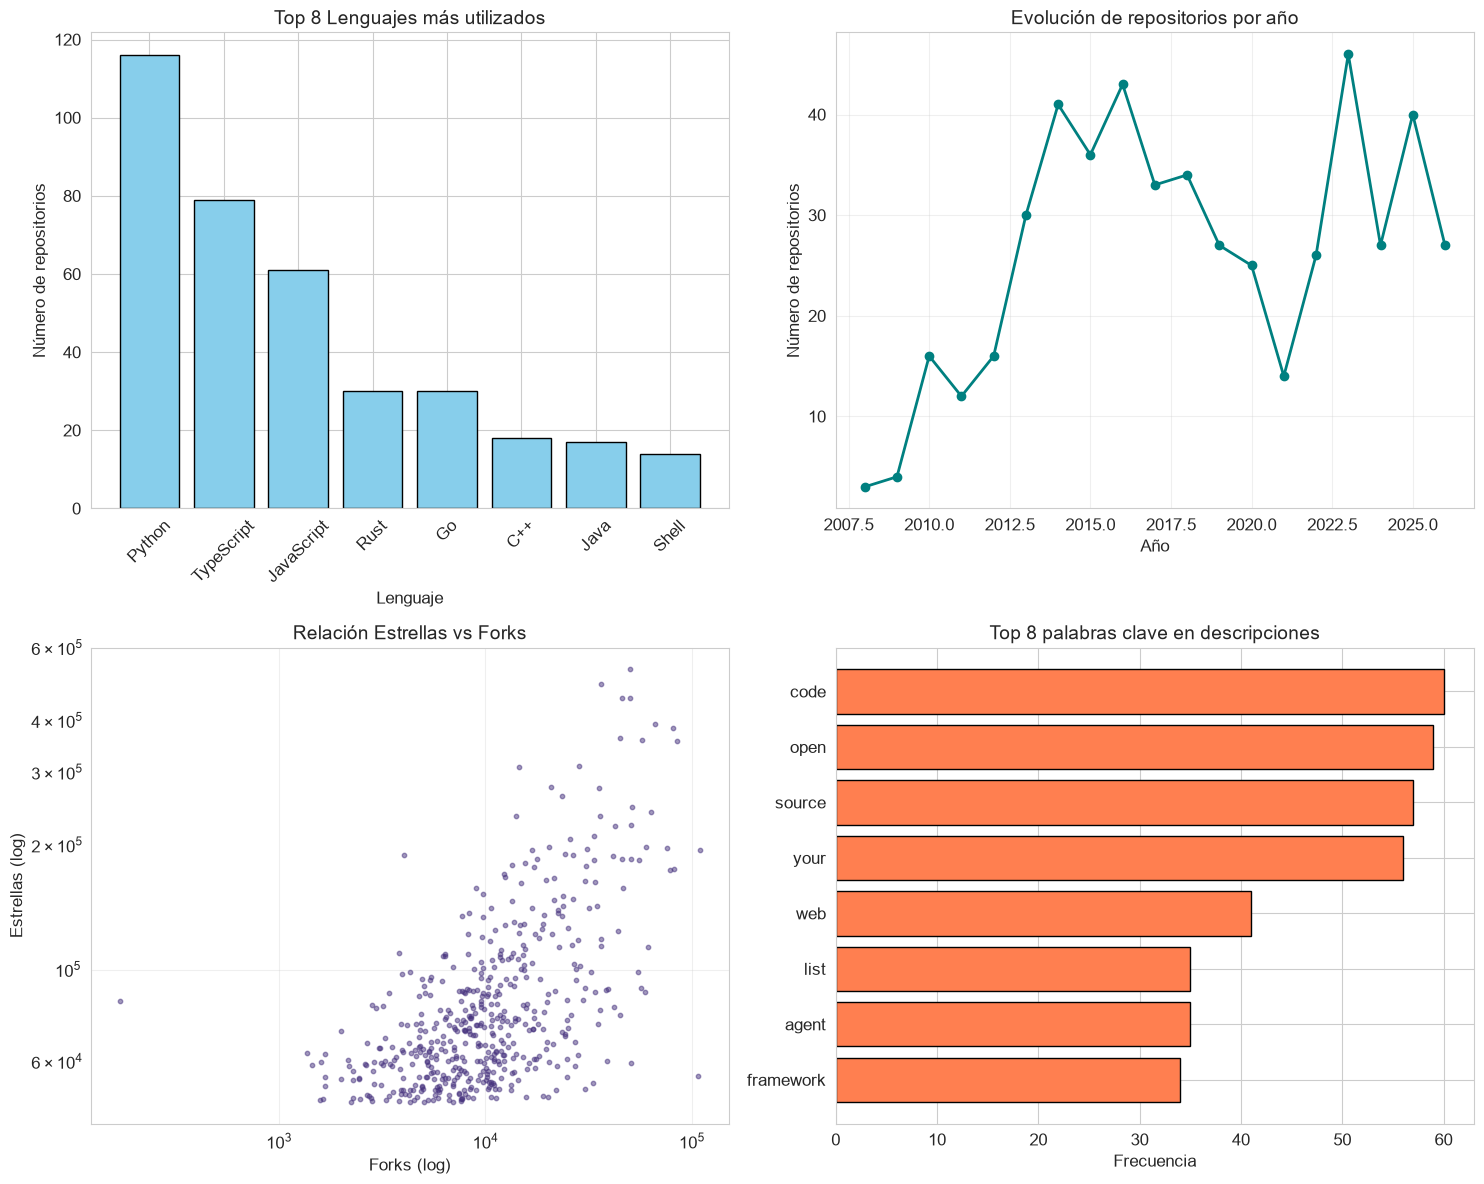

✅ Visualización resumen guardada como 'summary_visualization.png'


In [9]:
if not df.empty:
    # Crear una visualización resumen de los hallazgos más importantes
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Top lenguajes
    top_langs = df['language'].value_counts().head(8)
    axes[0,0].bar(top_langs.index, top_langs.values, color='skyblue', edgecolor='black')
    axes[0,0].set_title('Top 8 Lenguajes más utilizados', fontsize=14)
    axes[0,0].set_xlabel('Lenguaje')
    axes[0,0].set_ylabel('Número de repositorios')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # 2. Evolución de repositorios por año
    if 'year' in df.columns:
        year_counts = df['year'].value_counts().sort_index()
        axes[0,1].plot(year_counts.index, year_counts.values, marker='o', color='teal', linewidth=2)
        axes[0,1].set_title('Evolución de repositorios por año', fontsize=14)
        axes[0,1].set_xlabel('Año')
        axes[0,1].set_ylabel('Número de repositorios')
        axes[0,1].grid(True, alpha=0.3)
    
    # 3. Relación estrellas vs forks (scatter)
    axes[1,0].scatter(df['forks_count'], df['stargazers_count'], alpha=0.5, s=10)
    axes[1,0].set_xscale('log')
    axes[1,0].set_yscale('log')
    axes[1,0].set_xlabel('Forks (log)')
    axes[1,0].set_ylabel('Estrellas (log)')
    axes[1,0].set_title('Relación Estrellas vs Forks', fontsize=14)
    axes[1,0].grid(True, alpha=0.3)
    
    # 4. Top palabras clave (si existen)
    if all_keywords:
        top_words = word_freq.most_common(8)
        words, counts = zip(*top_words)
        axes[1,1].barh(words, counts, color='coral', edgecolor='black')
        axes[1,1].set_title('Top 8 palabras clave en descripciones', fontsize=14)
        axes[1,1].set_xlabel('Frecuencia')
        axes[1,1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('../data/summary_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Visualización resumen guardada como 'summary_visualization.png'")
else:
    print("⚠️ DataFrame vacío. No se pueden crear visualizaciones.")

## Resumen de este notebook

Hemos consolidado los hallazgos del análisis de tendencias en GitHub, identificando patrones clave en lenguajes de programación, popularidad, evolución temporal y temáticas dominantes.

**Principales conclusiones:**
- Python y JavaScript dominan el ecosistema.
- Los repositorios de recursos educativos y herramientas prácticas son los más populares.
- La actividad en GitHub ha crecido exponencialmente en los últimos años.
- Existe una fuerte correlación entre estrellas y forks.

**Próximos pasos sugeridos:**
- Ampliar la muestra y el período de análisis.
- Aplicar técnicas de machine learning para predecir popularidad.
- Explorar análisis de redes y colaboración entre contribuyentes.

**¡Proyecto completado!** 🎉